<a href="https://colab.research.google.com/github/JingyuHe02/COMP3132/blob/main/Lab_Week09/LabWeek09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LabWeek9: Prevent Overfitting - Part I

## Importing Dataset: IMDB

In [1]:
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] += 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Note:** We first encountered this dataset in `LabWeek5`. You can refer to that notebook for clarification on the text-to-numbers decoding process. Through vectorizing process we turn text data into vectors.

**Perform some sanity checks on the dataset:** For example, find the `shape` of the dataset and print samples to make sense of the data.

In [3]:
print('train_data shape:', train_data.shape)
print('test_data shape:', test_data.shape)
print('number of training reviews:', len(train_data))
print('number of test reviews:', len(test_data))
print('first training review length:', len(train_data[0]))
print('first training label:', train_labels[0])
print('x_train shape after vectorization:', x_train.shape)
print('x_test shape after vectorization:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('sample vectorized review (first 20 values):', x_train[0][:20])
print('first 10 labels:', train_labels[:10])

train_data shape: (25000,)
test_data shape: (25000,)
number of training reviews: 25000
number of test reviews: 25000
first training review length: 218
first training label: 1
x_train shape after vectorization: (25000, 10000)
x_test shape after vectorization: (25000, 10000)
y_train shape: (25000,)
y_test shape: (25000,)
sample vectorized review (first 20 values): [ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.  0.  0.  6.  3.  3.  4. 11.  3.
  3.  2.]
first 10 labels: [1 0 0 1 0 0 1 0 1 0]


## Fighting overfitting -  Reducing the network's size


The general workflow to find an appropriate model size is to start with relatively few layers and
parameters, and start increasing the size of the layers or adding new layers until you see diminishing returns with regard to the
validation loss.



**Note:** we use `test set` as our `validation set`.

**Complete the following code for `original model` architecture**

In [4]:
from keras import models
from keras import layers

original_model = models.Sequential()
original_model.add(layers.InputLayer(shape=(10000,)))
original_model.add(layers.Dense(16, activation='relu'))
original_model.add(layers.Dense(16, activation='relu'))
original_model.add(layers.Dense(1, activation='sigmoid'))

original_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])

In [ ]:
original_model.summary()

**Define another model with fewer parameters. 4 units in each hidden layer.**

In [5]:
smaller_model = models.Sequential()
smaller_model.add(layers.InputLayer(shape=(10000,)))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(1, activation='sigmoid'))

smaller_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['acc'])


**Train (1) original_model and (2) smaller_model seperately for `epochs=20` and `batch_size=512`. Also pass `x_test` and `y_test` as `validation_data`.**

In [6]:
original_hist = original_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - acc: 0.7807 - loss: 0.4951 - val_acc: 0.8775 - val_loss: 0.3562
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.8899 - loss: 0.3079 - val_acc: 0.8733 - val_loss: 0.3277
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.9147 - loss: 0.2399 - val_acc: 0.8673 - val_loss: 0.3409
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - acc: 0.9258 - loss: 0.2063 - val_acc: 0.8880 - val_loss: 0.2922
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.9354 - loss: 0.1828 - val_acc: 0.8824 - val_loss: 0.3104
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9415 - loss: 0.1633 - val_acc: 0.8822 - val_loss: 0.3116
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9470 - loss: 0.1509 - val_acc: 0.8818 - val_loss: 0.3210
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - acc: 0.9518 - loss: 0.1396 - val_acc: 0.8795 - val_loss: 0.3349
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - acc: 0.9579

In [7]:
smaller_hist = smaller_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - acc: 0.7649 - loss: 0.5604 - val_acc: 0.8512 - val_loss: 0.4564
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.8865 - loss: 0.3737 - val_acc: 0.8802 - val_loss: 0.3537
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.9117 - loss: 0.2848 - val_acc: 0.8854 - val_loss: 0.3195
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9262 - loss: 0.2372 - val_acc: 0.8885 - val_loss: 0.2983
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - acc: 0.9347 - loss: 0.2084 - val_acc: 0.8669 - val_loss: 0.3431
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9394 - loss: 0.1881 - val_acc: 0.8856 - val_loss: 0.2939
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9462 - loss: 0.1700 - val_acc: 0.8846 - val_loss: 0.2966
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9501 - loss: 0.1561 - val_acc: 0.8826 - val_loss: 0.3051
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9534

**`orginal_hist` and `smaller_hist` are `objects` returned after training the models.**
- We can get access to the `history` attribute of `origial_hist` object through dot operator.
- TODO: The history attribute is a data structure of type `dictionary` containing data about everything that happened during training. Show the `keys` of this `dictionary`.

In [8]:
print(original_hist.history)
print(original_hist.history.keys())

{'acc': [0.7806800007820129, 0.8899199962615967, 0.914680004119873, 0.9257599711418152, 0.9353600144386292, 0.9414799809455872, 0.9469599723815918, 0.9517999887466431, 0.9579200148582458, 0.9599199891090393, 0.9642400145530701, 0.9694799780845642, 0.9718800187110901, 0.9743199944496155, 0.9759200215339661, 0.9788399934768677, 0.9805999994277954, 0.9842399954795837, 0.9863200187683105, 0.9848799705505371], 'loss': [0.4951035976409912, 0.3079468011856079, 0.23986810445785522, 0.20632623136043549, 0.18279388546943665, 0.1633089780807495, 0.15085889399051666, 0.13960261642932892, 0.12693896889686584, 0.11647717654705048, 0.10625932365655899, 0.09508952498435974, 0.0886198952794075, 0.07759835571050644, 0.0764135867357254, 0.06794615834951401, 0.06337001919746399, 0.05444761738181114, 0.05095177888870239, 0.051923446357250214], 'val_acc': [0.8774799704551697, 0.8732799887657166, 0.8673200011253357, 0.8880400061607361, 0.8824399709701538, 0.8821600079536438, 0.8817600011825562, 0.87951999902

**Plot `val_loss` vs. epochs for both models in one plot**

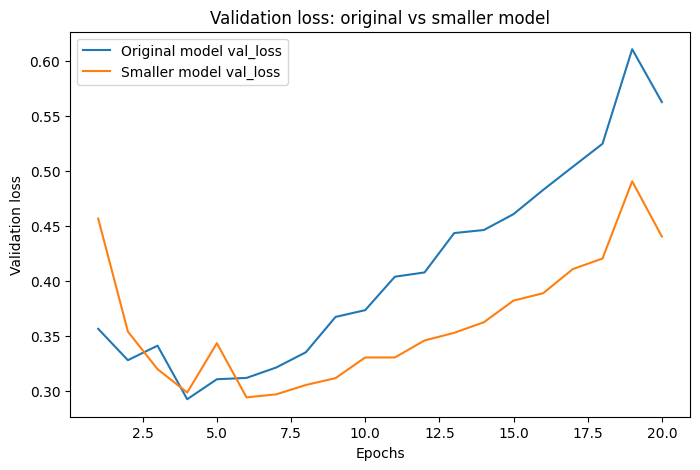

In [9]:
from matplotlib import pyplot as plt

epochs = range(1, len(original_hist.history['val_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_hist.history['val_loss'], label='Original model val_loss')
plt.plot(epochs, smaller_hist.history['val_loss'], label='Smaller model val_loss')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: original vs smaller model')
plt.legend()
plt.show()

**Plot training `loss` vs. epochs for both models in one plot**

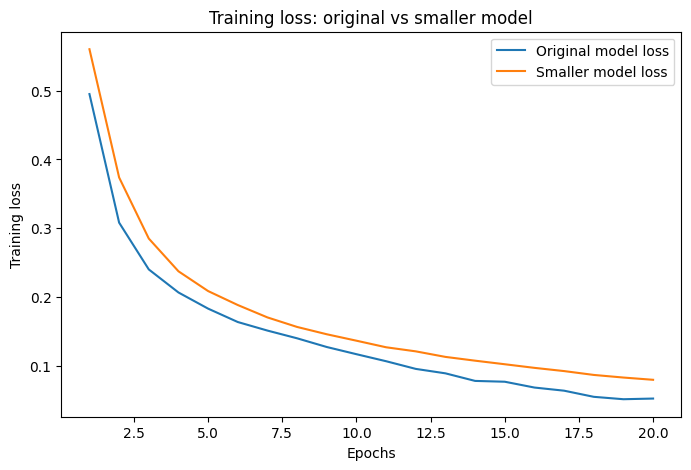

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, original_hist.history['loss'], label='Original model loss')
plt.plot(epochs, smaller_hist.history['loss'], label='Smaller model loss')
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.title('Training loss: original vs smaller model')
plt.legend()
plt.show()

**Questions:** Which model overfits earlier? How can you see the size of the model on overfitting?

**Answer:** The **original model** usually overfits earlier than the **smaller model**. We can see this when its training loss keeps going down, but its validation loss stops improving and starts going up sooner. This shows that a larger model has more capacity, so it can memorize the training data faster and overfit earlier.

**Now define a very large model (e.g., with 512 units in hidden layer) and compare the `loss` and `val_loss` of this big model and the `original model` and `smaller_model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 497ms/step - acc: 0.7292 - loss: 0.5939 - val_acc: 0.8381 - val_loss: 0.3987
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 368ms/step - acc: 0.8639 - loss: 0.3385 - val_acc: 0.8666 - val_loss: 0.3249
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 356ms/step - acc: 0.8992 - loss: 0.2505 - val_acc: 0.8407 - val_loss: 0.3712
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 468ms/step - acc: 0.9192 - loss: 0.1996 - val_acc: 0.8894 - val_loss: 0.2726
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 357ms/step - acc: 0.9360 - loss: 0.1664 - val_acc: 0.8884 - val_loss: 0.2846
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 470ms/step - acc: 0.9528 - loss: 0.1235 - val_acc: 0.8477 - val_loss: 0.4141
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step - acc: 0.9669 - loss: 0.0940 - val_acc: 0.8854 - val_loss: 0.3492
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 461ms/step - acc: 0.9756 - loss: 0.0813 - val_acc: 0.8820 - val_loss: 0.3889
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 381ms/

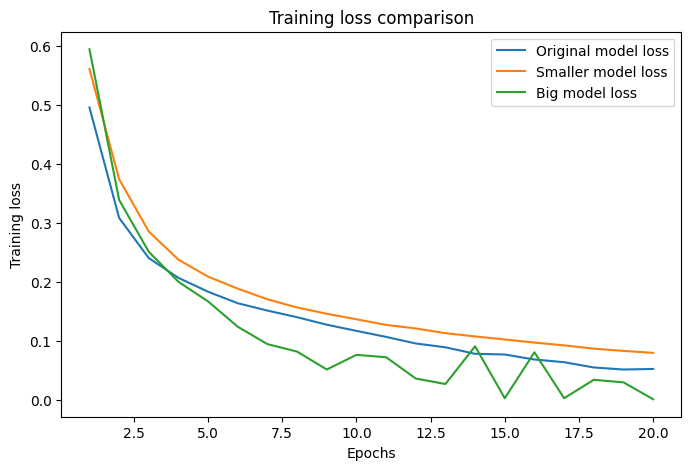

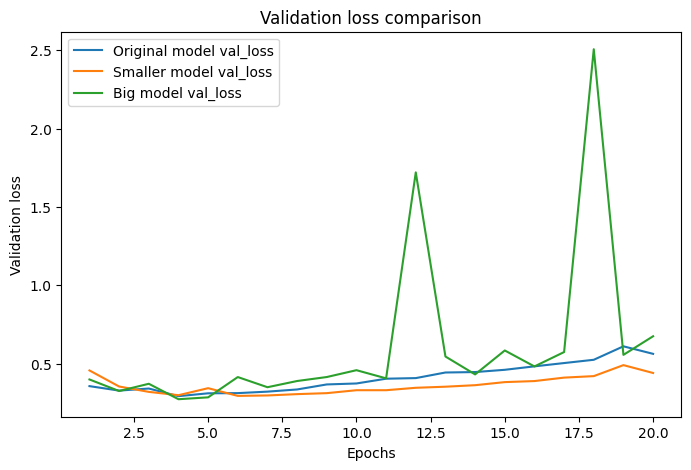

In [11]:
big_model = models.Sequential()
big_model.add(layers.InputLayer(shape=(10000,)))
big_model.add(layers.Dense(512, activation='relu'))
big_model.add(layers.Dense(512, activation='relu'))
big_model.add(layers.Dense(1, activation='sigmoid'))

big_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])

big_hist = big_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_hist.history['loss'], label='Original model loss')
plt.plot(epochs, smaller_hist.history['loss'], label='Smaller model loss')
plt.plot(epochs, big_hist.history['loss'], label='Big model loss')
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.title('Training loss comparison')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_hist.history['val_loss'], label='Original model val_loss')
plt.plot(epochs, smaller_hist.history['val_loss'], label='Smaller model val_loss')
plt.plot(epochs, big_hist.history['val_loss'], label='Big model val_loss')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss comparison')
plt.legend()
plt.show()

**Discuss the results**

**Answer:** The **big model** reaches very low training loss the fastest, which means it learns the training data very quickly. But its validation loss usually starts increasing the earliest, so it overfits the most. The **smaller model** learns more slowly, but its validation loss stays more stable for longer. The **original model** is in between these two.

## Fighting overfitting - Adding weight regularization


A common way to mitigate overfitting is to put constraints on the complexity
of a network by forcing its weights to only take small values. This is called
"weight regularization", and it is done by adding to the loss function of the network a _cost_ associated with having large weights. This
cost comes in two flavors:

* L1 regularization, where the cost added is proportional to the _absolute value of the weights coefficients_ (i.e. to what is called the
"L1 norm" of the weights).
* L2 regularization, where the cost added is proportional to the _square of the value of the weights coefficients_ (i.e. to what is called
the "L2 norm" of the weights). L2 regularization is also called _weight decay_ in the context of neural networks. Don't let the different
name confuse you: weight decay is mathematically the exact same as L2 regularization.

In Keras, weight regularization is added by passing _weight regularizer instances_ to layers as keyword arguments.


**Complere the model below**

In [12]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.InputLayer(shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

In [13]:
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value` to the total loss of
the network. Note that because this penalty is _only added at training time_, the loss for this network will be much higher at training
than at test time.



**Train the model with regularization and compare the validation loss between this model and the `original_model` and `smaller model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - acc: 0.7870 - loss: 0.5402 - val_acc: 0.8521 - val_loss: 0.4419
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - acc: 0.8913 - loss: 0.3599 - val_acc: 0.8810 - val_loss: 0.3663
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.9066 - loss: 0.3078 - val_acc: 0.8482 - val_loss: 0.4276
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.9181 - loss: 0.2806 - val_acc: 0.8876 - val_loss: 0.3411
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.9245 - loss: 0.2667 - val_acc: 0.8858 - val_loss: 0.3461
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - acc: 0.9258 - loss: 0.2602 - val_acc: 0.8811 - val_loss: 0.3582
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - acc: 0.9306 - loss: 0.2496 - val_acc: 0.8848 - val_loss: 0.3539
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9348 - loss: 0.2425 - val_acc: 0.8810 - val_loss: 0.3638
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9337

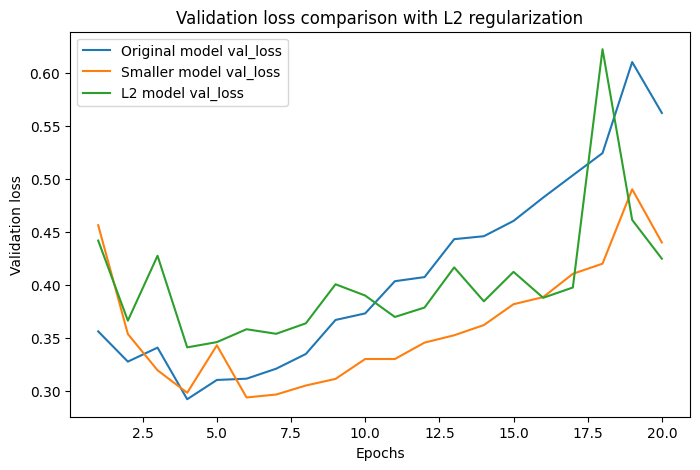

In [14]:
l2_hist = l2_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_hist.history['val_loss'], label='Original model val_loss')
plt.plot(epochs, smaller_hist.history['val_loss'], label='Smaller model val_loss')
plt.plot(epochs, l2_hist.history['val_loss'], label='L2 model val_loss')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss comparison with L2 regularization')
plt.legend()
plt.show()

**Note:** As alternatives to L2 regularization, you could use one of the following Keras weight regularizers:

In [15]:
from keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# L1 and L2 regularization at the same time
regularizers.l1_l2(l1=0.001, l2=0.001)

## Recap

To recap: here the most common ways to prevent overfitting in neural networks:

* Getting more training data.
* Reducing the capacity of the network.
* Adding weight regularization.
* Adding dropout. (next session)

**Observation 1:** The bigger network gets its training loss near zero very quickly. The more capacity the network has, the quicker it will be
able to model the training data (resulting in a low training loss), but the more susceptible it is to overfitting (resulting in a large
difference between the training and validation loss).

**Observation 2:** The model with L2 regularization has become much more resistant to overfitting than the reference model,
even though both models have the same number of parameters.